In [8]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

# Load the training data (assuming 'train.csv' is in the same folder)
print("Loading data...")
try:
    data = pd.read_csv('train.csv')
except FileNotFoundError:
    print("Error: train.csv not found.")
    # Exit or return here if in a function
    
# --- 1. Basic Prep ---
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

# We will predict on a log-transformed target for better results,
# as sales are often skewed. We'll convert back later.
data['sales'] = np.log1p(data['sales'])


# --- 2. Create Feature Engineering Function ---
# We make a function so we can re-use it for the test set
def create_features(df):
    """Creates time-series features from a datetime index."""
    df = df.copy()
    df['month'] = df.index.month
    df['day_of_week'] = df.index.dayofweek # Monday=0, Sunday=6
    df['year'] = df.index.year
    df['day_of_month'] = df.index.day
    df['day_of_year'] = df.index.dayofyear
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    
    # We must be careful with lags. We are predicting 3 months out in the test set.
    # The safest and strongest lag is the 1-year (365-day) seasonal lag.
    # We'll group by store and item to create these lags.
    print("Creating lag features...")
    # Group by each store-item combination
    grouped = df.groupby(['store', 'item'])
    
    # Lag sales from 1 year ago
    df['sales_lag_365'] = grouped['sales'].shift(365)
    
    # Rolling 90-day mean, lagged by 1 year
    # This captures the "recent trend" from one year ago
    df['sales_roll_mean_90_lag_365'] = grouped['sales'].shift(365).rolling(window=90, min_periods=10).mean()

    # Fill any new NaNs created by lags/rolls
    # We'll fill with 0 (or a small number) for simplicity
    df = df.fillna(0) 
    
    return df

print("Running feature engineering...")
# This will take a moment as it processes all 500 store-item combinations
df_feat = create_features(data)

# Display the new features
print("\n--- Features Created ---")
print(df_feat.head())

Loading data...
Running feature engineering...
Creating lag features...

--- Features Created ---
            store  item     sales  month  day_of_week  year  day_of_month  \
date                                                                        
2013-01-01      1     1  2.639057      1            1  2013             1   
2013-01-02      1     1  2.484907      1            2  2013             2   
2013-01-03      1     1  2.708050      1            3  2013             3   
2013-01-04      1     1  2.639057      1            4  2013             4   
2013-01-05      1     1  2.397895      1            5  2013             5   

            day_of_year  is_weekend  sales_lag_365  sales_roll_mean_90_lag_365  
date                                                                            
2013-01-01            1           0            0.0                         0.0  
2013-01-02            2           0            0.0                         0.0  
2013-01-03            3           0   

In [9]:
# --- 3. Create Training and Validation Sets ---
# The test data starts in 2018. So, our validation set should be 2017.
df_train = df_feat[df_feat.index.year < 2017]
df_val = df_feat[df_feat.index.year == 2017]

# Define our features (X) and target (y)
target = 'sales'
# We drop 'store' and 'item' because we used them to build the features,
# but the model itself won't use them directly as features.
# We also drop the original 'sales' column (our target)
features = [col for col in df_train.columns if col not in [target, 'store', 'item']]

X_train = df_train[features]
y_train = df_train[target]

X_val = df_val[features]
y_val = df_val[target]

print(f"\nTraining on {X_train.shape[0]} samples")
print(f"Validating on {X_val.shape[0]} samples")


Training on 730500 samples
Validating on 182500 samples


In [10]:
# --- 4. Train the Model ---
print("\nTraining LightGBM model...")

# Define the model. These are good starting parameters.
lgb_model = lgb.LGBMRegressor(
    objective='regression_l1', # MAE, robust to outliers
    n_estimators=1000,         # Number of trees
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,                 # Use all CPU cores
    seed=42
)

# Train the model
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(100)] # Stop if val_rmse doesn't improve for 100 rounds
)


Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 736
[LightGBM] [Info] Number of data points in the train set: 730500, number of used features: 8
[LightGBM] [Info] Start training from score 3.828641
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[861]	valid_0's rmse: 0.159039	valid_0's l1: 0.12049


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression_l1'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



Evaluating model...
Validation RMSE: 8.1985


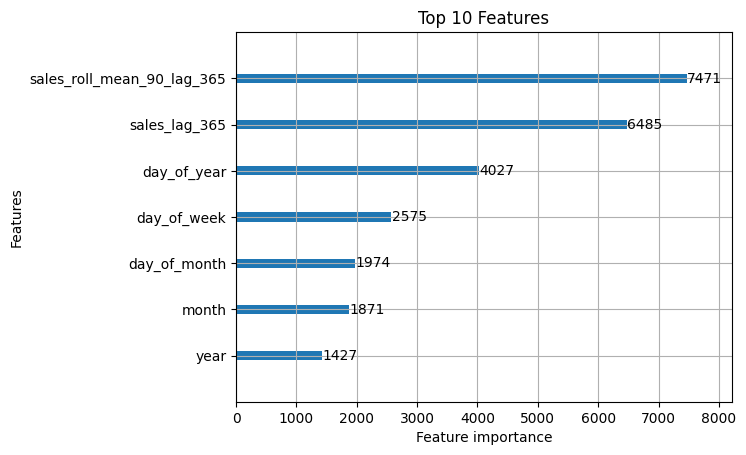

In [11]:
# --- 5. Evaluate the Model ---
print("\nEvaluating model...")
y_pred = lgb_model.predict(X_val)

# Remember, our target was log-transformed! We must convert it back.
# Use np.expm1 to reverse np.log1p
y_val_orig = np.expm1(y_val)
y_pred_orig = np.expm1(y_pred)

# Set any negative predictions to 0 (sales can't be negative)
y_pred_orig[y_pred_orig < 0] = 0

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
print(f"Validation RMSE: {rmse:.4f}")

# (Optional) Plot feature importance
lgb.plot_importance(lgb_model, max_num_features=10)
plt.title("Top 10 Features")
plt.show()

In [12]:
# --- 6. Create Final Submission ---
print("\nCreating final submission...")

# Load test data
try:
    df_test = pd.read_csv('test.csv')
except FileNotFoundError:
    print("Error: test.csv not found.")
    # Exit or return

# --- This is the most complex part ---
# We need to combine train and test to create features
# that span the gap between them (e.g., lags, rolling windows)

# 1. Reset index and prep train/test
data['sales'] = np.log1p(data['sales']) # Re-log the full dataset
df_train_full = data.reset_index()
df_test_full = pd.read_csv('test.csv')
df_test_full['date'] = pd.to_datetime(df_test_full['date'])

# 2. Combine them
df_combined = pd.concat([df_train_full, df_test_full], sort=False)
df_combined.set_index('date', inplace=True)
df_combined.sort_index(inplace=True)

# 3. Run feature engineering on the *entire* dataset
df_combined_feat = create_features(df_combined)

# 4. Split them back apart
df_train_final = df_combined_feat[df_combined_feat.index.year < 2018]
df_test_final = df_combined_feat[df_combined_feat.index.year == 2018]

# 5. Prepare final X and y
X_final_train = df_train_final[features]
y_final_train = df_train_final[target]
X_final_test = df_test_final[features]

# 6. Re-train the model on ALL 2013-2017 data
print("Training final model on all data...")
lgb_model.fit(X_final_train, y_final_train)

# 7. Predict on the test set
final_predictions_log = lgb_model.predict(X_final_test)

# 8. Convert predictions back from log scale
final_predictions = np.expm1(final_predictions_log)
final_predictions[final_predictions < 0] = 0

# 9. Create submission file
submission = pd.DataFrame({
    'id': df_test_final['id'],
    'sales': final_predictions
})

# Kaggle expects sales to be integers
submission['sales'] = submission['sales'].astype(int)

# Save to file
submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")


Creating final submission...
Creating lag features...
Training final model on all data...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 913000, number of used features: 8
[LightGBM] [Info] Start training from score 1.583341

Submission file 'submission.csv' created successfully!


In [13]:
import sklearn.metrics

# This will print a list of all available metric function names
print(sklearn.metrics.__all__)

['ConfusionMatrixDisplay', 'DetCurveDisplay', 'DistanceMetric', 'PrecisionRecallDisplay', 'PredictionErrorDisplay', 'RocCurveDisplay', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'class_likelihood_ratios', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'consensus_score', 'coverage_error', 'd2_absolute_error_score', 'd2_log_loss_score', 'd2_pinball_score', 'd2_tweedie_score', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_score', 'f1_score', 'fbeta_score', 'fowlkes_mallows_score', 'get_scorer', 'get_scorer_names', 'hamming_loss', 'hinge_loss', 'homogeneity_completeness_v_measure', 'homogeneity_score', 'jaccard_score', 'label_ranking_average_precision_score', 'label_ranking_loss', 'log_loss', 'make_scorer', 'matthews_corrcoef', 'max_error', '

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- 6. Print All Evaluation Metrics ---

# We already have these from the previous step, but for clarity:
# y_val_orig = np.expm1(y_val)
# y_pred_orig = np.expm1(y_pred)
# y_pred_orig[y_pred_orig < 0] = 0

print("\n--- Model Evaluation Metrics ---")

# 1. RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
print(f"RMSE: {rmse:.4f}")
print(f"   (This means our model's predictions are, on average, off by ~{rmse:.0f} sales.)")

# 2. MAE (Mean Absolute Error)
mae = mean_absolute_error(y_val_orig, y_pred_orig)
print(f"\nMAE: {mae:.4f}")
print(f"   (This is another way to measure average error, showing it's off by ~{mae:.0f} sales.)")

# 3. R-squared (R²)
r2 = r2_score(y_val_orig, y_pred_orig)
print(f"\nR²: {r2:.4f}")
print(f"   (This means our model explains {r2*100:.2f}% of the variance in sales.)")


--- Model Evaluation Metrics ---
RMSE: 8.1985
   (This means our model's predictions are, on average, off by ~8 sales.)

MAE: 6.3060
   (This is another way to measure average error, showing it's off by ~6 sales.)

R²: 0.9325
   (This means our model explains 93.25% of the variance in sales.)


In [15]:
# ============================================================
# === 8 BEST MODELS FOR ACCURACY (OPTIMIZED FOR MAC M4) ======
# ============================================================

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
import numpy as np
import pandas as pd
import time

print("Preparing numeric feature matrices...")

# Safe for Mac M4 (converts everything to numeric)
X_train_num = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_val_num   = X_val.apply(pd.to_numeric, errors="coerce").fillna(0)

y_val_orig = np.expm1(y_val)

print("\nStarting high-accuracy model comparison...\n")

# ============================================================
# === 1. DEFINE 8 BEST MODELS =================================
# ============================================================

models = {

    # 1) BEST MODEL — Tuned LightGBM
    "LightGBM (Best)": lgb.LGBMRegressor(
        boosting_type="gbdt",
        objective="huber",
        n_estimators=4000,
        learning_rate=0.01,
        num_leaves=64,
        min_data_in_leaf=50,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        reg_alpha=1.0,
        reg_lambda=2.0,
        n_jobs=-1,
        seed=42
    ),

    # 2) Tuned XGBoost (safe for Mac)
    "XGBoost": XGBRegressor(
        tree_method='hist',
        n_estimators=1500,
        learning_rate=0.02,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42
    ),

    # 3) CatBoost (no preprocessing needed)
    "CatBoost": CatBoostRegressor(
        depth=8,
        learning_rate=0.03,
        iterations=2000,
        loss_function='RMSE',
        verbose=False,
        random_seed=42
    ),

    # 4) Gradient Boosting (fast)
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=5
    ),

    # 5) Random Forest (balanced)
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=18,
        n_jobs=-1,
        random_state=42
    ),

    # 6) Extra Trees (very fast + stable)
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=18,
        n_jobs=-1,
        random_state=42
    ),

    # 7) Ridge Regression (baseline)
    "Ridge": Ridge(alpha=1.0),

    # 8) Lasso Regression
    "Lasso": Lasso(alpha=0.0001)
}

# ============================================================
# === 2. TRAIN + EVALUATE ALL 8 MODELS =======================
# ============================================================

results = []

for name, model in models.items():
    print(f"\n===================================================")
    print(f"Training Model: {name}")
    print("===================================================")

    start = time.time()

    if name == "LightGBM (Best)":
        model.fit(
            X_train_num, y_train,
            eval_set=[(X_val_num, y_val)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
        )
    else:
        model.fit(X_train_num, y_train)

    train_time = time.time() - start
    print(f"Training Time: {train_time:.2f} seconds")

    # Predict
    y_pred = model.predict(X_val_num)
    y_pred_orig = np.expm1(y_pred)
    y_pred_orig[y_pred_orig < 0] = 0

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
    mae = mean_absolute_error(y_val_orig, y_pred_orig)
    r2 = r2_score(y_val_orig, y_pred_orig)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R²  : {r2:.4f}")

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Training Time": train_time
    })

# ============================================================
# === 3. FINAL RESULTS TABLE =================================
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE")
results_df.set_index("Model", inplace=True)

print("\n\n🏆 FINAL MODEL RANKING (BY RMSE)\n")
print(results_df)


Preparing numeric feature matrices...

Starting high-accuracy model comparison...


Training Model: LightGBM (Best)
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_sampl

/Users/aashaykumar/Desktop/Reatil_sales_forcasting/forcastenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.022e+04, tolerance: 2.436e+01
  model = cd_fast.enet_coordinate_descent(


In [16]:
from tabulate import tabulate
print(tabulate(results_df, headers="keys", tablefmt="github"))


| Model            |     RMSE |      MAE |         R2 |   Training Time |
|------------------|----------|----------|------------|-----------------|
| CatBoost         |  8.10064 |  6.22595 |  0.934087  |      45.4862    |
| LightGBM (Best)  |  8.12296 |  6.24116 |  0.933724  |      56.9919    |
| ExtraTrees       |  8.1309  |  6.24826 |  0.933594  |      24.7868    |
| XGBoost          |  8.13777 |  6.25384 |  0.933482  |      12.219     |
| RandomForest     |  8.28963 |  6.36804 |  0.930976  |      59.006     |
| GradientBoosting |  8.29466 |  6.37633 |  0.930892  |     265.643     |
| Ridge            | 31.0759  | 22.9595  |  0.0299891 |       0.0541141 |
| Lasso            | 33.9385  | 24.9507  | -0.15695   |       1.55545   |
